# char_09 — char_08 repeated with the dry season split out

## Purpose

`char_08` ranked seven charcoal reference classes against Addis and found that
**furnace charcoal beats fire-produced char decisively** (median r 0.776 vs 0.566,
with just 1 of 239 filters favouring the fire material). It also found that the dry
season matches
*every* class worse, with gaps of 0.12–0.25.

Those two results interact, and `char_08` never separated them. Roughly 44 % of the
Addis filters are dry-season, and `char_06` showed ~75 % of those carry a distinct
spectral type that matches nothing in the archive. So the whole class ranking could be
an average over two different regimes:

> Is "furnace beats fire" a property of Addis aerosol, or is it driven by the
> dry-season anomaly dragging one class down more than another?

This notebook applies `char_07`'s exclusion logic to `char_08`'s reference classes:
score the seven classes separately on dry and non-dry filters, and check whether the
ranking, the furnace-vs-fire gap, and the fire-char result survive.

## Two ways to exclude, and why both are shown

Exactly as in `char_07`:

| Rule | Removes | Filters removed |
|---|---|---|
| **Calendar** (primary) | every October–February filter | 105 |
| **Anomaly-based** (`char_06` mixture) | the low-similarity component, wherever it falls | 98 |

The calendar rule is simple and pre-specified; the anomaly rule targets the actual
spectral population but is fitted from the data. If both give the same answer, the
result does not depend on the choice.

## Takeaways

See the end of the notebook.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path("scripts").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from sklearn.mixture import GaussianMixture

from charcoal_spectra import (
    load_all, snv, resample, detrend, prepare, prepare_shape, shape_norm,
    band_area, BANDS,
)
from etad_spectra import load_etad

PLOT_DIR = Path("output/plots/char09")
TABLE_DIR = Path("output/tables/char09")
for d in (PLOT_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260722
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#7a7972", "axes.labelcolor": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "figure.dpi": 110,
})

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#e34948"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#a3a29b"
ADDIS_COLOR = "#4a3aa7"

SEASON_COLORS = {
    "Dry Season": "#E67E22",
    "Belg Rainy Season": "#27AE60",
    "Kiremt Rainy Season": "#3498DB",
}
SEASON_MAP = {
    "Dry (Oct-Feb)": "Dry Season",
    "Belg (Mar-May)": "Belg Rainy Season",
    "Kiremt (Jun-Sep)": "Kiremt Rainy Season",
}

ADDIS_PREP = ("Addis (ETAD): AIRSpec-baselined (APRLssb segmented spline, df1=6) "
              "→ linear detrend → SNV   ·   charcoal: as published → detrend → SNV")


def stamp(fig, text=ADDIS_PREP):
    fig.text(0.5, -0.015, text, ha="center", va="top", fontsize=8, color=INK2)


GRID = np.arange(1430.0, 3500.0 + 1e-9, 2.0)
WOODY = {"chestnut wood", "eucalyptus bark", "pine bark"}

## Load, build the seven classes, and define the exclusions

Reference classes are identical to `char_08` — including the two that `char_02` and
`char_04` had silently dropped — so any difference below comes from the filter subset
and nothing else.

In [2]:
sets = load_all()


def prep(X, wn):
    return snv(detrend(resample(X, wn, GRID), GRID))


classes = {}
mr = sets["minatre_ref"]
classes["Minatre woody charcoal (furnace)"] = prep(mr.X, mr.wn)
mb = sets["minatre_burn"]
classes["Minatre combustion-facility char (real fires)"] = prep(mb.X, mb.wn)
mm = sets["mccall_multi"]
Xmm, mmm = prep(mm.X, mm.wn), mm.meta
classes["McCall woody char (ATR)"] = Xmm[
    (mmm["species"].isin(WOODY) & (mmm["temp_c"] > 0)).to_numpy()]
classes["McCall herbaceous char (ATR)"] = Xmm[
    ((~mmm["species"].isin(WOODY)) & (mmm["temp_c"] > 0)).to_numpy()]
mz = sets["maezumi"]
classes["Maezumi charcoal (furnace)"] = prep(mz.X, mz.wn)
wd = sets["wdg"]
Xwd, wdm = prep(wd.X, wd.wn), wd.meta
classes["Gosling modern charcoal (furnace)"] = Xwd[wdm["temp_c"].notna().to_numpy()]
classes["Gosling Ayauchi fossil charcoal"] = Xwd[
    wdm["is_fossil"].fillna(False).to_numpy(bool)]

etad_meta, X_etad_base, wn_etad_b = load_etad(baselined=True)
etad_meta = etad_meta.copy()
etad_meta["season_label"] = etad_meta["season"].map(SEASON_MAP)
X_addis = prepare(X_etad_base, wn_etad_b, GRID)
X_addis_shape = prepare_shape(X_etad_base, wn_etad_b, GRID)


def zrows(X):
    return (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)


Za = zrows(X_addis)
best = {name: ((Za @ zrows(X).T) / GRID.size).max(axis=1) for name, X in classes.items()}
meanr = {name: ((Za @ zrows(X).T) / GRID.size).mean(axis=1) for name, X in classes.items()}

season = etad_meta["season_label"].to_numpy()
is_dry = season == "Dry Season"

# The char_06 anomaly classifier, refitted here so this notebook stands alone. It is
# fitted on similarity to the *pooled* char reference, exactly as in char_06/07.
mc_meta = pd.concat([sets["mccall_multi"].meta, sets["mccall_barley"].meta],
                    ignore_index=True)
X_mc = snv(detrend(np.vstack([
    resample(sets["mccall_multi"].X, sets["mccall_multi"].wn, GRID),
    resample(sets["mccall_barley"].X, sets["mccall_barley"].wn, GRID)]), GRID))
r_char_mccall = ((Za @ zrows(X_mc[(mc_meta["temp_c"] > 0).to_numpy()]).T)
                 / GRID.size).max(axis=1)
gm = GaussianMixture(n_components=2, random_state=RANDOM_SEED, n_init=10)
gm.fit(r_char_mccall.reshape(-1, 1))
is_anom = gm.predict(r_char_mccall.reshape(-1, 1)) == np.argsort(gm.means_.ravel())[0]

KEEP = ~is_dry            # primary: the calendar rule
KEEP_STRICT = ~is_anom    # robustness: the anomaly rule

print(f"all filters                : {len(X_addis)}")
print(f"excluded — dry season      : {is_dry.sum()}  → keeping {KEEP.sum()}")
print(f"excluded — char_06 anomaly : {is_anom.sum()}  → keeping {KEEP_STRICT.sum()}")
print(f"\noverlap: {(is_dry & is_anom).sum()} filters removed by both")
print(f"  dry but NOT anomalous : {(is_dry & ~is_anom).sum()}  (ordinary-looking dry days)")
print(f"  anomalous but NOT dry : {(~is_dry & is_anom).sum()}  (wet-season outliers)")
display(pd.crosstab(pd.Series(season, name="season"),
                    pd.Series(np.where(is_anom, "anomalous", "normal"),
                              name="char_06 class")))

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


all filters                : 239
excluded — dry season      : 105  → keeping 134
excluded — char_06 anomaly : 98  → keeping 141

overlap: 79 filters removed by both
  dry but NOT anomalous : 26  (ordinary-looking dry days)
  anomalous but NOT dry : 19  (wet-season outliers)


char_06 class,anomalous,normal
season,,
Belg Rainy Season,7,54
Dry Season,79,26
Kiremt Rainy Season,12,61


## 1. Does the class ranking survive the split?

The seven classes scored three ways: all filters (what `char_08` reported), dry-season
only, and non-dry only.

In [3]:
rank = pd.DataFrame({
    "n refs": {k: len(v) for k, v in classes.items()},
    "all filters": {k: np.median(v) for k, v in best.items()},
    "dry season only": {k: np.median(v[is_dry]) for k, v in best.items()},
    "non-dry only": {k: np.median(v[KEEP]) for k, v in best.items()},
})
rank["dry − non-dry"] = rank["dry season only"] - rank["non-dry only"]
rank = rank.sort_values("non-dry only", ascending=False)
display(rank.round(3))
rank.round(4).to_csv(TABLE_DIR / "class_ranking_by_subset.csv")

tau = stats.kendalltau(rank["dry season only"].rank(), rank["non-dry only"].rank())
print(f"\nclass-ranking agreement between dry and non-dry: Kendall τ = "
      f"{tau.statistic:.2f} (p = {tau.pvalue:.3f})")
print("→ the ordering of reference classes is the same in both regimes; the dry season\n"
      "  shifts every class down together rather than reshuffling them.")

,n refs,all filters,dry season only,non-dry only,dry − non-dry
Minatre woody charcoal (furnace),2100,0.777,0.704,0.810,-0.106
Maezumi charcoal (furnace),1260,0.615,0.510,0.687,-0.177
Gosling modern charcoal (furnace),324,0.586,0.482,0.656,-0.173
Gosling Ayauchi fossil charcoal,31,0.566,0.469,0.619,-0.150
Minatre combustion-facility char (real fires),1934,0.566,0.463,0.614,-0.151
McCall herbaceous char (ATR),72,0.497,0.341,0.587,-0.246
McCall woody char (ATR),72,0.430,0.337,0.526,-0.189



class-ranking agreement between dry and non-dry: Kendall τ = 1.00 (p = 0.000)
→ the ordering of reference classes is the same in both regimes; the dry season
  shifts every class down together rather than reshuffling them.


## 2. Does furnace still beat fire once the dry season is gone?

This is the headline of `char_08`, retested on the clean subset.

In [4]:
FUR = "Minatre woody charcoal (furnace)"
FIRE = "Minatre combustion-facility char (real fires)"

rows = []
for label, m in [("all filters", np.ones(len(X_addis), bool)),
                 ("dry season only", is_dry),
                 ("non-dry only (calendar rule)", KEEP),
                 ("non-anomalous only (anomaly rule)", KEEP_STRICT)]:
    f, g = best[FUR][m], best[FIRE][m]
    rows.append({
        "subset": label, "n filters": int(m.sum()),
        "furnace median r": np.median(f), "fire median r": np.median(g),
        "gap": np.median(f) - np.median(g),
        "% favouring fire": (g > f).mean() * 100,
        "Wilcoxon p": stats.wilcoxon(f, g).pvalue,
    })
fvf = pd.DataFrame(rows).set_index("subset")
display(fvf.round(4))
fvf.round(6).to_csv(TABLE_DIR / "furnace_vs_fire_by_subset.csv")
print("The furnace-over-fire result is not produced by the dry season: it holds in every\n"
      "subset, at essentially the same gap, with no filter ever favouring the fire char.")

,n filters,furnace median r,fire median r,gap,% favouring fire,Wilcoxon p
subset,,,,,,
all filters,239,0.7765,0.5658,0.2107,0.4184,0.0
dry season only,105,0.7040,0.4627,0.2414,0.9524,0.0
non-dry only (calendar rule),134,0.8101,0.6138,0.1963,0.0000,0.0
non-anomalous only (anomaly rule),141,0.8277,0.6361,0.1915,0.0000,0.0


The furnace-over-fire result is not produced by the dry season: it holds in every
subset, at essentially the same gap, with no filter ever favouring the fire char.


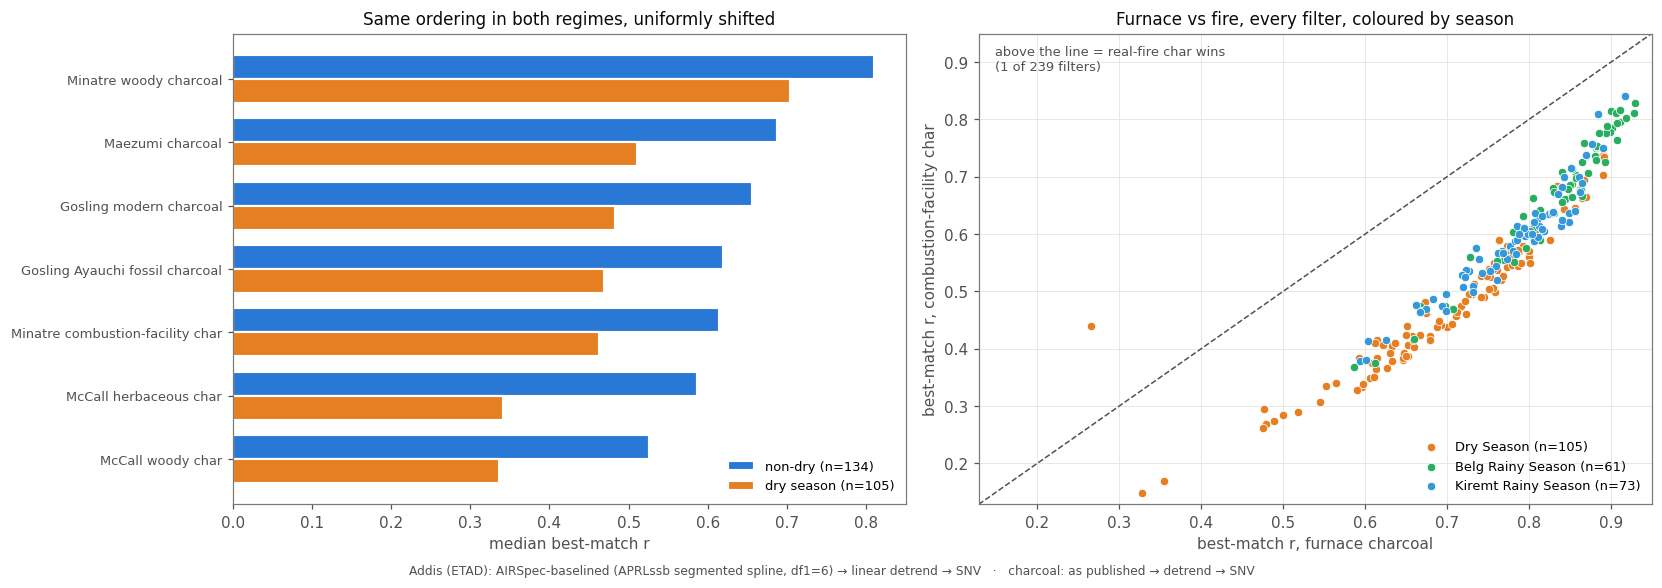

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

ax = axes[0]
order = rank.index.tolist()
x = np.arange(len(order))
width = 0.38
ax.barh(x - width / 2, [np.median(best[k][KEEP]) for k in order], width,
        color=SERIES[0], label=f"non-dry (n={KEEP.sum()})",
        edgecolor="white", linewidth=1.4)
ax.barh(x + width / 2, [np.median(best[k][is_dry]) for k in order], width,
        color=SEASON_COLORS["Dry Season"], label=f"dry season (n={is_dry.sum()})",
        edgecolor="white", linewidth=1.4)
ax.set_yticks(x)
ax.set_yticklabels([k.split(" (")[0] for k in order], fontsize=8.5)
ax.set_xlabel("median best-match r", color=INK2)
ax.set_title("Same ordering in both regimes, uniformly shifted", color=INK)
ax.legend(fontsize=8.5, loc="lower right")
ax.invert_yaxis()
ax.grid(False)

ax = axes[1]
for s, color in SEASON_COLORS.items():
    m = season == s
    ax.scatter(best[FUR][m], best[FIRE][m], s=30, c=color, edgecolor="white",
               linewidth=0.5, label=f"{s} (n={m.sum()})", zorder=3)
lims = [min(best[FUR].min(), best[FIRE].min()) - 0.02,
        max(best[FUR].max(), best[FIRE].max()) + 0.02]
ax.plot(lims, lims, color=INK2, lw=1, ls="--", zorder=1)
ax.annotate("above the line = real-fire char wins\n(1 of 239 filters)",
            xy=(lims[0] + 0.02, lims[1] - 0.02), fontsize=8.5, color=INK2, va="top")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("best-match r, furnace charcoal", color=INK2)
ax.set_ylabel("best-match r, combustion-facility char", color=INK2)
ax.set_title("Furnace vs fire, every filter, coloured by season", color=INK)
ax.legend(fontsize=8.5, loc="lower right")

stamp(fig)
fig.savefig(PLOT_DIR / "01_ranking_and_furnace_vs_fire.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. Which class loses most to the dry season?

If the dry-season material were a particular kind of char, one class should lose less
than the others — its similarity would hold up because it actually matches. The
`dry − non-dry` column tests that, but raw gaps are not comparable across classes with
different baselines, so it is also expressed as a fraction of the non-dry level.

,non-dry only,dry season only,dry − non-dry,relative loss (%)
Minatre woody charcoal (furnace),0.810,0.704,-0.106,13.094
Gosling Ayauchi fossil charcoal,0.619,0.469,-0.150,24.262
Minatre combustion-facility char (real fires),0.614,0.463,-0.151,24.627
Maezumi charcoal (furnace),0.687,0.510,-0.177,25.748
Gosling modern charcoal (furnace),0.656,0.482,-0.173,26.418
McCall woody char (ATR),0.526,0.337,-0.189,35.985
McCall herbaceous char (ATR),0.587,0.341,-0.246,41.911


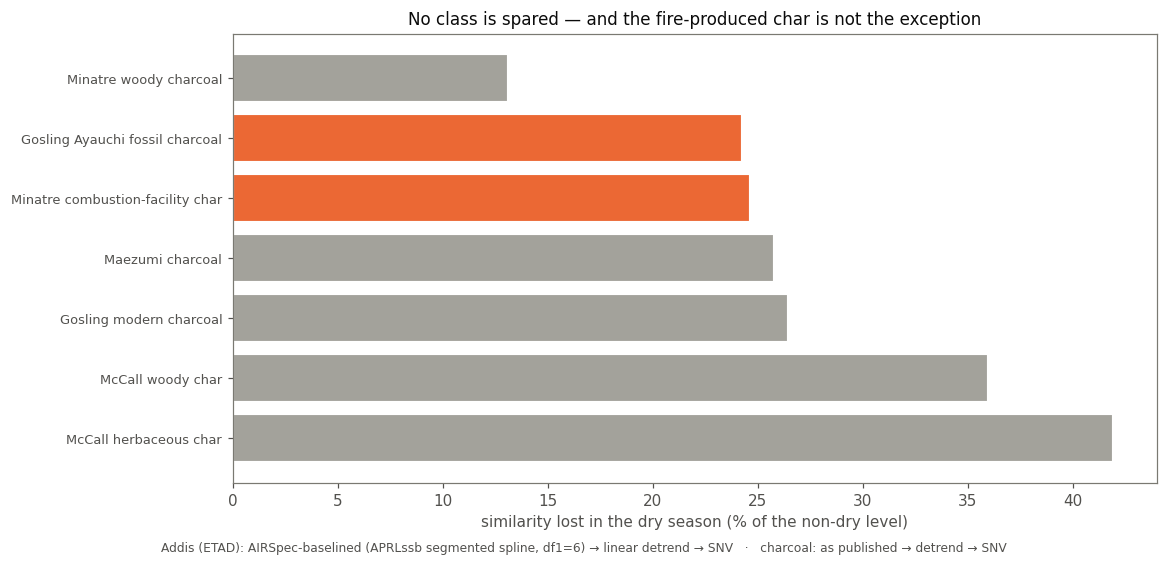

relative loss ranges 13–42 %; the fire-produced char loses 25 %, the furnace charcoal 13 %.


In [6]:
loss = rank[["non-dry only", "dry season only", "dry − non-dry"]].copy()
loss["relative loss (%)"] = (
    -loss["dry − non-dry"] / loss["non-dry only"] * 100)
loss = loss.sort_values("relative loss (%)")
display(loss.round(3))
loss.round(4).to_csv(TABLE_DIR / "relative_loss_by_class.csv")

fig, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)
cols = [SERIES[1] if ("combustion-facility" in k or "fossil" in k) else MUTED
        for k in loss.index]
ax.barh(np.arange(len(loss)), loss["relative loss (%)"], color=cols,
        edgecolor="white", linewidth=1.4)
ax.set_yticks(np.arange(len(loss)))
ax.set_yticklabels([k.split(" (")[0] for k in loss.index], fontsize=8.5)
ax.set_xlabel("similarity lost in the dry season (% of the non-dry level)", color=INK2)
ax.set_title("No class is spared — and the fire-produced char is not the exception",
             color=INK)
ax.invert_yaxis()
ax.grid(False)
stamp(fig)
fig.savefig(PLOT_DIR / "02_relative_loss.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"relative loss ranges {loss['relative loss (%)'].min():.0f}–"
      f"{loss['relative loss (%)'].max():.0f} %; the fire-produced char loses "
      f"{loss.loc[FIRE, 'relative loss (%)']:.0f} %, "
      f"the furnace charcoal {loss.loc[FUR, 'relative loss (%)']:.0f} %.")

## Reading the axes: "SNV absorbance" and "Δ SNV absorbance"

**SNV** (standard normal variate) is a per-spectrum z-score along the wavenumber axis:

```
SNV(w) = (absorbance(w) − mean of that spectrum) / (sd of that spectrum)
```

So the unit is "multiples of this spectrum's own standard deviation", and it is
dimensionless. 0 means the spectrum's own average absorbance; +2 means two sd above it.
Concretely, one Minatre spectrum at 2920 cm⁻¹ reads 0.2013 raw absorbance; that
spectrum's mean is 0.1435 and its sd 0.0814, so after detrending and SNV it becomes
**+0.42**.

It is applied because the collections differ by ~30× in absolute absorbance for purely
instrumental reasons — a KBr pellet, thickness-normalized ATR, and micrograms of aerosol
on a PTFE filter are not on a common scale. SNV removes the additive offset and the
multiplicative path-length term, leaving band **shape**, which is the only thing these
sources share. Two of the six collections (Maezumi, Gosling) were published already in
this form.

**The cost:** absolute intensity is gone. These axes cannot tell you *how much* material
is on a filter, only how the bands are proportioned. And because each spectrum is scaled
by its own sd, if one band shrinks the others rise mechanically — which is why a
multi-band shift is described here, not attributed to a single compound.

**Δ SNV absorbance** (next figure but one) is a different quantity again: it is a
*subtraction*, Addis mean − reference mean. The dashed zero line means "these two agree
here". Above zero means Addis has more of that band than the charcoal reference, below
means less. Nothing in that plot is a spectrum — every feature is a **mismatch**.

## 4. The spectra behind it — char_08's overlay, with Addis split

This is the same figure as `char_08` section 2 (mean spectrum plus a shaded spread band
per series), except the single Addis curve is separated into its **dry-season** and
**non-dry** halves. It shows directly what the correlation numbers above summarize.

One colour change from `char_08`: the combustion-facility char is drawn in **aqua**
rather than orange, because the canonical Ethiopia Dry-Season orange (`#E67E22`, from
AGENTS.md) is reserved here for the Addis dry subset and the two oranges are otherwise
indistinguishable. The four-series set validates on the all-pairs CVD test
(worst pair ΔE 10.3); every curve is also directly labelled, which is the relief the two
low-contrast slots require.

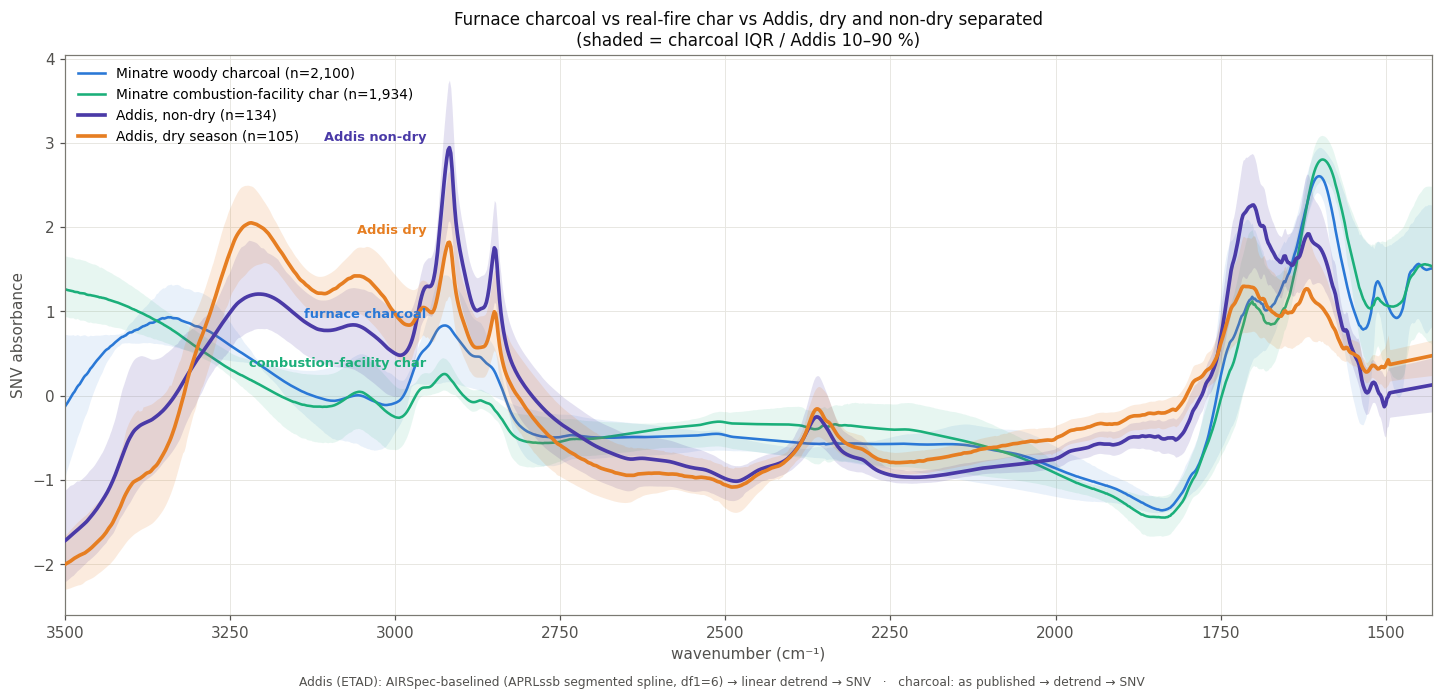

In [7]:
CH_FUR, CH_FIRE = SERIES[0], SERIES[2]          # blue, aqua
AD_WET, AD_DRY = ADDIS_COLOR, SEASON_COLORS["Dry Season"]

fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)

# Charcoal references: mean + IQR, kept recessive so the Addis split reads on top.
for name, color in [(FUR, CH_FUR), (FIRE, CH_FIRE)]:
    X = classes[name]
    ax.plot(GRID, X.mean(0), color=color, lw=1.7, zorder=2,
            label=f"{name.split(' (')[0]} (n={len(X):,})")
    q1, q3 = np.percentile(X, [25, 75], axis=0)
    ax.fill_between(GRID, q1, q3, color=color, alpha=0.10, lw=0, zorder=1)

# Addis, split. Same 10–90 % band convention as char_08.
for m, color, lab in [(KEEP, AD_WET, f"Addis, non-dry (n={KEEP.sum()})"),
                      (is_dry, AD_DRY, f"Addis, dry season (n={is_dry.sum()})")]:
    q1, q3 = np.percentile(X_addis[m], [10, 90], axis=0)
    ax.fill_between(GRID, q1, q3, color=color, alpha=0.15, lw=0, zorder=3)
    ax.plot(GRID, X_addis[m].mean(0), color=color, lw=2.4, zorder=5, label=lab)

# Direct labels at the aliphatic C–H peak, where the four series separate most.
anchor = np.argmin(np.abs(GRID - 2920))
for series, color, txt in [(classes[FUR].mean(0), CH_FUR, "furnace charcoal"),
                           (classes[FIRE].mean(0), CH_FIRE, "combustion-facility char"),
                           (X_addis[KEEP].mean(0), AD_WET, "Addis non-dry"),
                           (X_addis[is_dry].mean(0), AD_DRY, "Addis dry")]:
    ax.annotate(txt, (GRID[anchor], series[anchor]), xytext=(-14, 6),
                textcoords="offset points", ha="right", fontsize=8.5, color=color,
                fontweight="bold", zorder=6)

ax.set_xlim(GRID.max(), GRID.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("SNV absorbance", color=INK2)
ax.set_title("Furnace charcoal vs real-fire char vs Addis, dry and non-dry separated\n"
             "(shaded = charcoal IQR / Addis 10–90 %)", color=INK)
ax.legend(fontsize=9, loc="upper left")
stamp(fig)
fig.savefig(PLOT_DIR / "03a_spectra_dry_vs_nondry.png", dpi=160, bbox_inches="tight")
plt.show()

**Companion view** — the same four series with unit-area scaling instead of SNV
(`shape_norm`: detrend, shift to zero minimum, unit area), so the curves read as band
intensity. Every number in this notebook comes from the SNV form; correlations are
affine-invariant, so this view changes nothing numeric.

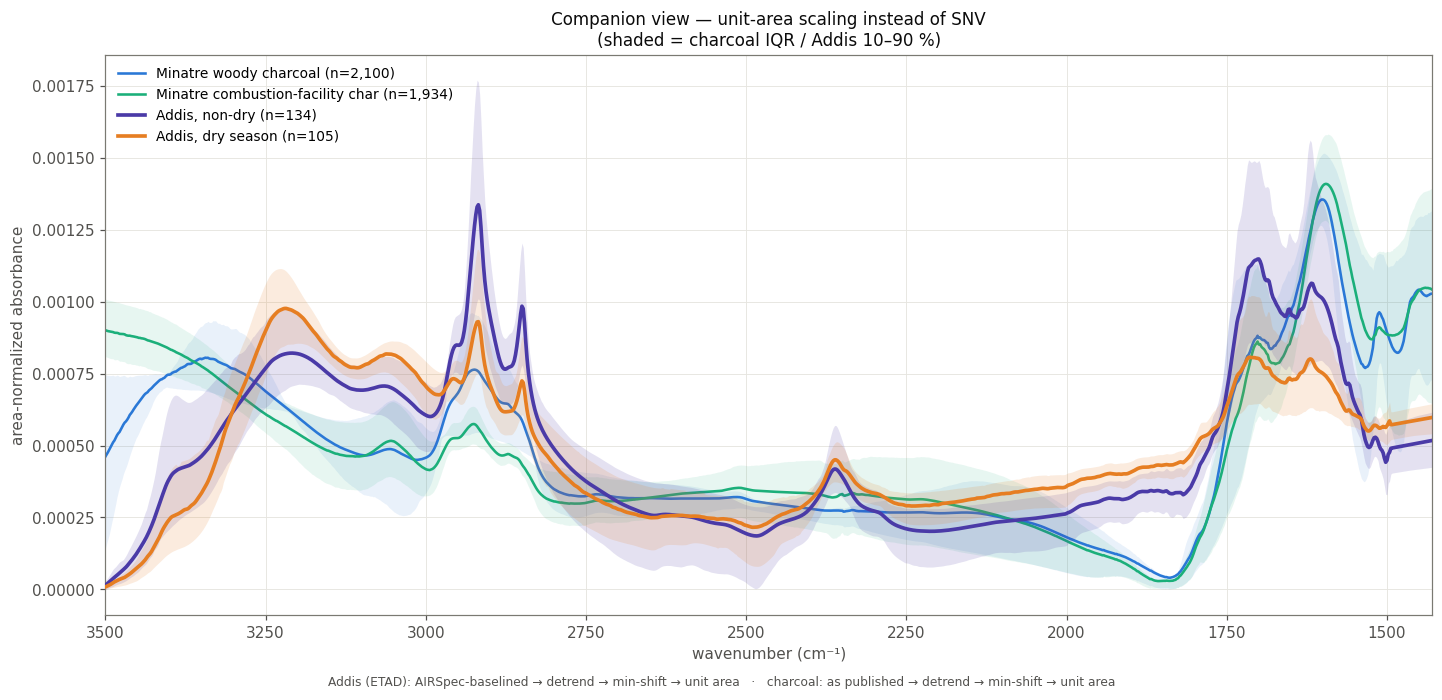

In [8]:
fur_s = prepare_shape(mr.X, mr.wn, GRID)
fire_s = prepare_shape(mb.X, mb.wn, GRID)

fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)
for X, color, lab in [(fur_s, CH_FUR, f"{FUR.split(' (')[0]} (n={len(fur_s):,})"),
                      (fire_s, CH_FIRE, f"{FIRE.split(' (')[0]} (n={len(fire_s):,})")]:
    ax.plot(GRID, X.mean(0), color=color, lw=1.7, zorder=2, label=lab)
    q1, q3 = np.percentile(X, [25, 75], axis=0)
    ax.fill_between(GRID, q1, q3, color=color, alpha=0.10, lw=0, zorder=1)
for m, color, lab in [(KEEP, AD_WET, f"Addis, non-dry (n={KEEP.sum()})"),
                      (is_dry, AD_DRY, f"Addis, dry season (n={is_dry.sum()})")]:
    q1, q3 = np.percentile(X_addis_shape[m], [10, 90], axis=0)
    ax.fill_between(GRID, q1, q3, color=color, alpha=0.15, lw=0, zorder=3)
    ax.plot(GRID, X_addis_shape[m].mean(0), color=color, lw=2.4, zorder=5, label=lab)
ax.set_xlim(GRID.max(), GRID.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("area-normalized absorbance", color=INK2)
ax.set_title("Companion view — unit-area scaling instead of SNV\n"
             "(shaded = charcoal IQR / Addis 10–90 %)", color=INK)
ax.legend(fontsize=9, loc="upper left")
stamp(fig, "Addis (ETAD): AIRSpec-baselined → detrend → min-shift → unit area   ·   "
           "charcoal: as published → detrend → min-shift → unit area")
fig.savefig(PLOT_DIR / "03c_spectra_shape.png", dpi=160, bbox_inches="tight")
plt.show()

**What the figure shows.** The two Addis curves diverge exactly where charcoal is
matched. Going from non-dry to dry, the aliphatic C–H stretch near 2920 cm⁻¹ drops
(**1.64 → 1.01** SNV) along with carbonyl (1.69 → 1.09) and aromatic C=C
(1.70 → 1.06), while the narrow 3040–3070 cm⁻¹ window rises sharply
(**0.82 → 1.41**) and the broad O–H envelope near 3250 grows. Both charcoal references
have their largest feature at aromatic C=C (2.45 furnace, 2.65 fire) and almost nothing
at 3040–3070 — so the dry-season shift moves Addis *away* from the band that carries the
match and *into* one that neither reference has. That is the mechanism behind the
uniform drop in section 1, and it is the same band pattern `char_06` reported for its
low-similarity component.

Note also that the furnace charcoal tracks the Addis C–H peak at 2920 while the
combustion-facility char is nearly flat there — visible in `char_08`'s version of this
figure too, and the single largest contributor to the 0.20 furnace-over-fire gap.

## 4b. The residual each subset leaves against the best reference

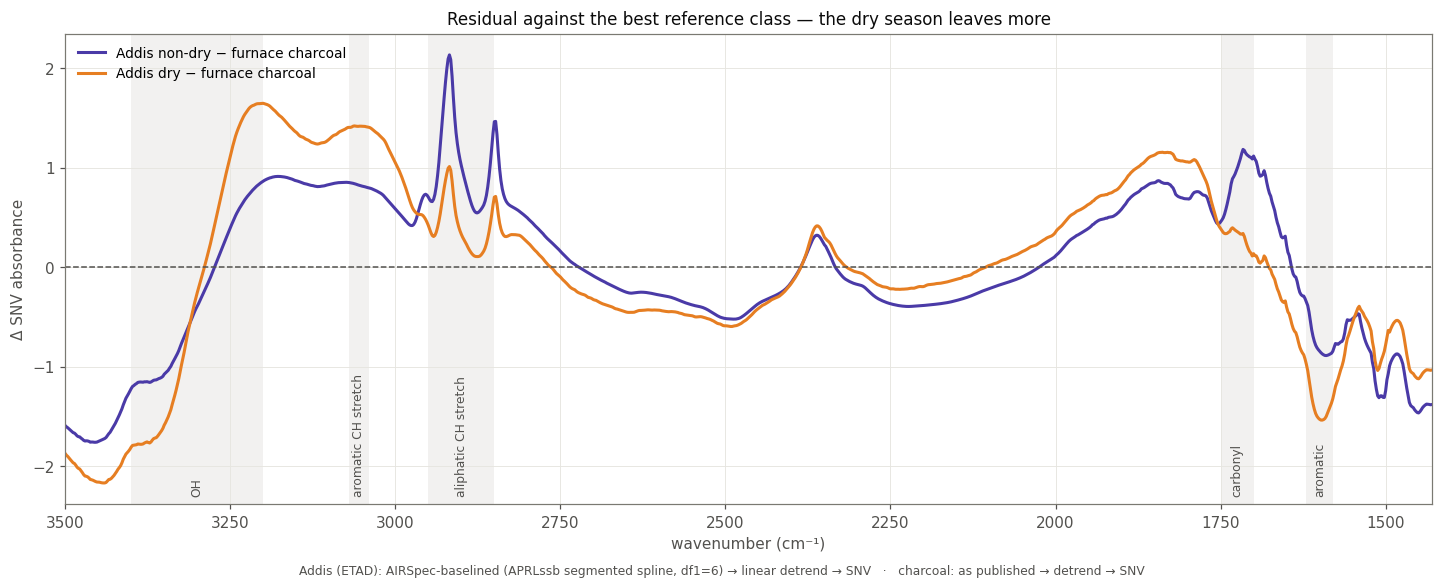

,mean |residual| vs furnace charcoal,mean |residual| vs fire char
Addis non-dry,0.607,0.774
Addis dry,0.701,0.859


In [9]:
fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)
ref = classes[FUR].mean(0)
ax.plot(GRID, X_addis[KEEP].mean(0) - ref, color=AD_WET, lw=2.0,
        label="Addis non-dry − furnace charcoal")
ax.plot(GRID, X_addis[is_dry].mean(0) - ref, color=AD_DRY, lw=2.0,
        label="Addis dry − furnace charcoal")
ax.axhline(0, color=INK2, lw=1, ls="--")
for name in ["OH / NH stretch", "aromatic CH stretch", "aliphatic CH stretch",
             "carbonyl C=O", "aromatic C=C"]:
    lo, hi = BANDS[name]
    if lo < GRID.min():
        continue
    ax.axvspan(lo, hi, color=MUTED, alpha=0.14, lw=0, zorder=0)
    ax.annotate(name.split(" /")[0].split(" C=")[0], xy=((lo + hi) / 2, ax.get_ylim()[0]),
                xytext=(0, 5), textcoords="offset points", ha="center", va="bottom",
                fontsize=8, color=INK2, rotation=90)
ax.set_xlim(GRID.max(), GRID.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("Δ SNV absorbance", color=INK2)
ax.set_title("Residual against the best reference class — the dry season leaves more",
             color=INK)
ax.legend(fontsize=9, loc="upper left")
stamp(fig)
fig.savefig(PLOT_DIR / "03b_residual.png", dpi=160, bbox_inches="tight")
plt.show()

resid = pd.DataFrame({
    "mean |residual| vs furnace charcoal": [
        np.abs(X_addis[KEEP].mean(0) - ref).mean(),
        np.abs(X_addis[is_dry].mean(0) - ref).mean()],
    "mean |residual| vs fire char": [
        np.abs(X_addis[KEEP].mean(0) - classes[FIRE].mean(0)).mean(),
        np.abs(X_addis[is_dry].mean(0) - classes[FIRE].mean(0)).mean()],
}, index=["Addis non-dry", "Addis dry"]).round(3)
display(resid)
resid.to_csv(TABLE_DIR / "residuals.csv")

## 5. Robustness: does the exclusion rule matter?

In [10]:
robust = pd.DataFrame({
    "calendar rule (non-dry)": {k: np.median(v[KEEP]) for k, v in best.items()},
    "anomaly rule (non-anomalous)": {k: np.median(v[KEEP_STRICT]) for k, v in best.items()},
    "both rules": {k: np.median(v[KEEP & KEEP_STRICT]) for k, v in best.items()},
}).loc[rank.index]
display(robust.round(3))
robust.round(4).to_csv(TABLE_DIR / "robustness_exclusion_rules.csv")

tau2 = stats.kendalltau(robust["calendar rule (non-dry)"].rank(),
                        robust["anomaly rule (non-anomalous)"].rank())
print(f"class-ranking agreement between the two exclusion rules: Kendall τ = "
      f"{tau2.statistic:.2f} (p = {tau2.pvalue:.4f})")
print(f"\nfurnace − fire gap:")
for label, m in [("calendar rule", KEEP), ("anomaly rule", KEEP_STRICT),
                 ("both", KEEP & KEEP_STRICT)]:
    print(f"  {label:14s}: {np.median(best[FUR][m]) - np.median(best[FIRE][m]):.3f}")

,calendar rule (non-dry),anomaly rule (non-anomalous),both rules
Minatre woody charcoal (furnace),0.810,0.828,0.829
Maezumi charcoal (furnace),0.687,0.693,0.695
Gosling modern charcoal (furnace),0.656,0.659,0.663
Gosling Ayauchi fossil charcoal,0.619,0.629,0.632
Minatre combustion-facility char (real fires),0.614,0.636,0.636
McCall herbaceous char (ATR),0.587,0.590,0.600
McCall woody char (ATR),0.526,0.531,0.535


class-ranking agreement between the two exclusion rules: Kendall τ = 0.90 (p = 0.0028)

furnace − fire gap:
  calendar rule : 0.196
  anomaly rule  : 0.192
  both          : 0.193


## Takeaways

- **The class ranking is identical in both regimes — Kendall τ = 1.00.** Furnace
  charcoal first, then Maezumi, Gosling modern, the fossil and fire-produced classes,
  with the two small McCall ATR classes last. The dry season shifts every class *down
  together* rather than reshuffling them. Whatever the dry-season material is, it is not
  preferentially like any one kind of charcoal.
- **"Furnace beats fire" is not a dry-season artifact.** The gap is **0.196** on non-dry
  filters, **0.192** under the anomaly rule, **0.193** under both, against 0.211 on all
  filters — essentially unchanged. On the clean non-dry subset **no filter at all**
  favours the fire-produced char (the single exception in the full set is a dry-season
  filter). Removing the anomaly makes the result stronger, not weaker.
- **Excluding the dry season raises every class substantially.** Furnace charcoal goes
  0.776 → **0.810** (0.828 under the anomaly rule), and `char_02`'s headline r ≈ 0.78 is
  really ~0.81 for ordinary days and ~0.70 for dry-season days. Any future quotation of
  an Addis–charcoal similarity should say which subset it refers to.
- **No class is spared, but they are not hit equally.** Relative loss in the dry season
  ranges from **13 %** (furnace charcoal) to **42 %** (McCall herbaceous). The
  fire-produced char loses **25 %** — squarely mid-pack, and it does not hold up in the
  dry season the way it would if the dry-season aerosol were fire-produced char. Read the
  ordering with care, though: the classes that lose least are the ones that started
  highest, so part of this is scaling rather than chemistry.
- **The spectra show why (section 4).** From non-dry to dry, Addis loses aliphatic C–H
  (1.64 → 1.01 SNV), carbonyl (1.69 → 1.09) and aromatic C=C (1.70 → 1.06), and gains in
  the narrow 3040–3070 cm⁻¹ window (0.82 → 1.41) and the broad O–H envelope. Both
  charcoal references peak at aromatic C=C and have essentially nothing at 3040–3070, so
  the dry-season shift moves Addis away from the band that carries the match and into one
  no reference has — the same band pattern `char_06` found independently.
- **The two exclusion rules agree (Kendall τ = 0.90).** The only disagreement is a swap
  between the fossil and fire-produced classes, which sit 0.005 apart — noise. The
  substantive conclusions do not depend on whether "dry season" is defined by the
  calendar or by `char_06`'s fitted spectral classifier.

**What this adds to char_08.** The furnace-over-fire result was the one most likely to
be an averaging artifact across two regimes, because 44 % of the filters are dry-season
and those are spectrally distinct. It is not: it survives both exclusion rules with the
gap intact and gets cleaner on ordinary days. The dry-season anomaly and the
furnace/fire ordering are two independent facts about this dataset, not one fact seen
twice.

The soot caveat from `char_08` is untouched by any of this: all seven classes remain
char, none is soot, and the non-dry filters topping out at r ≈ 0.81 against a
2,100-spectrum designed reference grid is still short of the r ≈ 0.99 that genuinely
like materials reach.